In [ ]:
## SIDEWALKS

In [252]:
import geopandas as gpd

url = (
    "https://arcgis.dvrpc.org/portal/rest/services/transportation/pedestriannetwork_lines/FeatureServer/0/query?outFields=*&where=1%3D1&f=geojson"
)

ped = gpd.read_file(url)


In [253]:
ped.columns

Index(['objectid', 'line_type', 'material', 'material_o', 'feat_type',
       'raised', 'width', 'captured', 'state', 'county', 'muni', 'community',
       'ped_sig', 'created_user', 'created_date', 'last_edited_user',
       'last_edited_date', 'vertchange', 'cracking', 'cross_slope',
       'fix_obstr', 'veg', 'over_obj', 'buff_zone', 'st_light', 'tree',
       'cond_date', 'notes', 'globalid', 'Shape__Length', 'geometry'],
      dtype='object')

In [254]:
#THIS WILL BE USED AT THE END
#I WANT TO CALCULATE INDEX FOR WHOLE CITY FIRST
import geopandas as gpd
tracts = gpd.read_file("philly_neighborhoods.geojson")
# Ensure CRS matches
tracts = tracts.to_crs("EPSG:3857")   
eptracts = tracts[tracts["Name"].str.contains("PASSYUNK_SQUARE", case=False, na=False)]

ped_ep= gpd.sjoin(ped, eptracts, how="inner", predicate="within")


C:\Users\kalmanj\AppData\Local\Temp\ipykernel_17932\4084788930.py:9: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: EPSG:4326
Right CRS: EPSG:3857

  ped_ep= gpd.sjoin(ped, eptracts, how="inner", predicate="within")


In [255]:

# Example counts (adjust field names to match your data)
# Count sidewalk gaps
if "SIDEWALK" in ped.columns:
    sidewalk_gaps = ped["SIDEWALK"].value_counts()
    print("Sidewalk counts / gaps:\n", sidewalk_gaps)

# Count ADA ramps
if "ADA_RAMP" in ped.columns:
    ada_ramps = ped["ADA_RAMP"].value_counts()
    print("ADA ramps counts:\n", ada_ramps)

# Count crosswalks
if "CROSSWALK" in ped.columns:
    crosswalks = ped["CROSSWALK"].value_counts()
    print("Crosswalk counts:\n", crosswalks)

# Optional: summarize total counts
print("Total sidewalk segments:", len(ped))
if "ADA_RAMP" in ped.columns:
    print("Total ADA ramps:", ped_ep["ADA_RAMP"].sum())
if "CROSSWALK" in ped.columns:
    print("Total crosswalks:", ped_ep["CROSSWALK"].sum())

Total sidewalk segments: 2000


In [259]:
ped= ped[ped['county'].str.upper() == "PHILADELPHIA"].copy()


In [260]:
ped

,objectid,line_type,material,material_o,feat_type,raised,width,captured,state,county,...,veg,over_obj,buff_zone,st_light,tree,cond_date,notes,globalid,Shape__Length,geometry
1,521594,2,N/A,None,CONTINENTAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{06E4B466-8D25-4D3C-9D43-68FCFA70BD31},0.00,"LINESTRING (-75.20583 39.94976, -75.20569 39.9..."
3,521596,1,CONCRETE,None,PATH,N/A,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{2F1A9BE4-C5FC-4AC1-B6B0-2AF166FEE0FE},0.00,"LINESTRING (-75.18103 39.94216, -75.181 39.942..."
8,549424,2,N/A,None,DIAGONAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{F44B7C5F-11A5-40E6-A240-2EBC9103CC6B},0.00,"LINESTRING (-75.23366 39.94476, -75.23359 39.9..."
10,521600,1,CONCRETE,None,PATH,N/A,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{B85EE0B7-5214-4E3A-9D58-428C2D74D0DE},0.00,"LINESTRING (-75.18251 39.94244, -75.1825 39.94..."
12,549425,2,N/A,None,CONTINENTAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{E7111C3A-BEB3-4039-8D16-981B5DAE955B},0.00,"LINESTRING (-75.08574 40.04799, -75.08586 40.0..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1950,549380,2,N/A,None,CONTINENTAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{F3A4F108-08DF-41DC-916D-7C71AEE2B3CD},0.00,"LINESTRING (-75.17254 39.91958, -75.17252 39.9..."
1951,549381,2,N/A,None,CONTINENTAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{0F31A67F-695A-4E90-85C3-535F6445931C},0.00,"LINESTRING (-75.09166 40.0322, -75.09181 40.03..."
1954,549382,2,N/A,None,CONTINENTAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{41E869E4-EE58-4481-862F-8CC85C66A820},0.00,"LINESTRING (-75.13008 40.00717, -75.13003 40.0..."
1955,549383,2,N/A,None,CONTINENTAL,NO,None,OTHER,PA,PHILADELPHIA,...,None,None,None,None,None,None,None,{211BA4C0-AD3A-476E-B8E0-9F3DC9554452},0.00,"LINESTRING (-75.15941 39.94637, -75.15942 39.9..."


In [261]:
import pandas as pd
pd.set_option('display.float_format', '{:,.2f}'.format)
tracts = tracts.to_crs("EPSG:32618")   
tracts['area_m2'] = tracts.geometry.area
tracts

,Name,geometry,area_m2
0,LAWNDALE,"POLYGON ((492650.696 4433325.065, 492414.12 44...","3,537,467.57"
1,ASTON_WOODBRIDGE,"POLYGON ((499266.779 4433715.944, 499265.975 4...","1,321,478.09"
2,CARROLL_PARK,"POLYGON ((480639.751 4425251.523, 481194.846 4...","1,217,644.48"
3,CHESTNUT_HILL,"POLYGON ((481860.144 4437364.762, 481864.814 4...","7,396,101.84"
4,BURNHOLME,"POLYGON ((492523.34 4435376.009, 492531.278 44...","978,620.44"
...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((486974.299 4419683.824, 486930.502 4...","453,072.28"
154,GARDEN_COURT,"POLYGON ((481707.565 4422575.867, 481660.947 4...","295,741.10"
155,WISSAHICKON_HILLS,"POLYGON ((481222.501 4431949.862, 481176.751 4...","282,463.83"
156,DEARNLEY_PARK,"POLYGON ((478557.527 4432621.566, 478665.632 4...","1,502,227.41"


In [262]:
total_area_m2 = tracts['area_m2'].sum()
print(f"Total area: {total_area_m2:,.2f} m²")


Total area: 369,285,108.40 m²


In [263]:
# Ensure the CRS is in meters for length calculation
ped = ped.to_crs(epsg=32618)
ped["length_m"] = ped.geometry.length

total_length = ped["length_m"].sum()
print("Total pedestrian network length (meters):", total_length)


Total pedestrian network length (meters): 9707.951473400504


In [316]:
import geopandas as gpd

# Reproject to projected CRS for accurate length/area
tracts = tracts.to_crs(epsg=32618)
ped = ped.to_crs(epsg=32618)

# Spatial join: assign each sidewalk segment to a tract
sidewalk_by_neighborhood = gpd.sjoin(tracts, ped, how='left', predicate='intersects')

# Aggregate total sidewalk length per neighborhood
sidewalk_summary = sidewalk_by_neighborhood.groupby('Name').agg({
    'geometry': 'first',    # keep the tract geometry
    'length_m': 'sum'       # sum of sidewalk lengths
}).reset_index()

# Convert to GeoDataFrame
sidewalk_summary = gpd.GeoDataFrame(sidewalk_summary, geometry='geometry', crs=tracts.crs)

# Compute tract area in m² (make sure the tracts have 'area_m2' column)
sidewalk_summary['area_m2'] = tracts['area_m2']

sidewalk_summary = sidewalk_summary[sidewalk_summary['length_m'] > 0].copy()


# Sidewalk density in meters per hectare
sidewalk_summary['sidewalk_density'] = (sidewalk_summary['length_m']) / sidewalk_summary['area_m2']

sidewalk_summary['geometry']= tracts.geometry
# Normalize density to 0-1 index
import numpy as np

# Remove zero-length tracts first
sidewalk_summary = sidewalk_summary[sidewalk_summary['length_m'] > 0].copy()

# Get min and max densities among non-zero values
min_density = sidewalk_summary.loc[sidewalk_summary['sidewalk_density'] > 0, 'sidewalk_density'].min()
max_density = sidewalk_summary['sidewalk_density'].max()

# Compute normalized index
sidewalk_summary['sidewalk_index'] = (sidewalk_summary['sidewalk_density'] - min_density) / (max_density - min_density)

# Replace negative values (if any) with 0
sidewalk_summary['sidewalk_index'] = sidewalk_summary['sidewalk_index'].clip(lower=0)

# Inspect
print(sidewalk_summary[['Name', 'length_m', 'area_m2', 'sidewalk_density', 'sidewalk_index']].head())



               Name  length_m       area_m2  sidewalk_density  sidewalk_index
0   ACADEMY_GARDENS     18.97  3,537,467.57              0.00            0.00
5   BARTRAM_VILLAGE    313.98    346,928.58              0.00            0.11
6       BELLA_VISTA      9.22    770,370.35              0.00            0.00
7           BELMONT      2.05  5,808,794.31              0.00            0.00
11        BUSTLETON    543.33 10,640,030.65              0.00            0.01


In [317]:
sidewalk_summary.sidewalk_density.max()

0.007940462610851249

In [318]:
sidewalk_summary

,Name,geometry,length_m,area_m2,sidewalk_density,sidewalk_index
0,ACADEMY_GARDENS,"POLYGON ((492650.696 4433325.065, 492414.12 44...",18.97,"3,537,467.57",0.00,0.00
5,BARTRAM_VILLAGE,"POLYGON ((501647.413 4434978.906, 501502.146 4...",313.98,"346,928.58",0.00,0.11
6,BELLA_VISTA,"POLYGON ((488506.519 4432874.16, 488499.742 44...",9.22,"770,370.35",0.00,0.00
7,BELMONT,"POLYGON ((483651.066 4428183.872, 483610.532 4...",2.05,"5,808,794.31",0.00,0.00
11,BUSTLETON,"POLYGON ((498690.501 4438276.638, 498101.589 4...",543.33,"10,640,030.65",0.00,0.01
...,...,...,...,...,...,...
151,WISSAHICKON_PARK,"POLYGON ((484646.487 4421718.354, 485851.26 44...",26.36,"1,307,805.32",0.00,0.00
153,WISTER,"POLYGON ((486974.299 4419683.824, 486930.502 4...",7.31,"453,072.28",0.00,0.00
154,WOODLAND_TERRACE,"POLYGON ((481707.565 4422575.867, 481660.947 4...",65.67,"295,741.10",0.00,0.03
155,WYNNEFIELD,"POLYGON ((481222.501 4431949.862, 481176.751 4...",2.20,"282,463.83",0.00,0.00


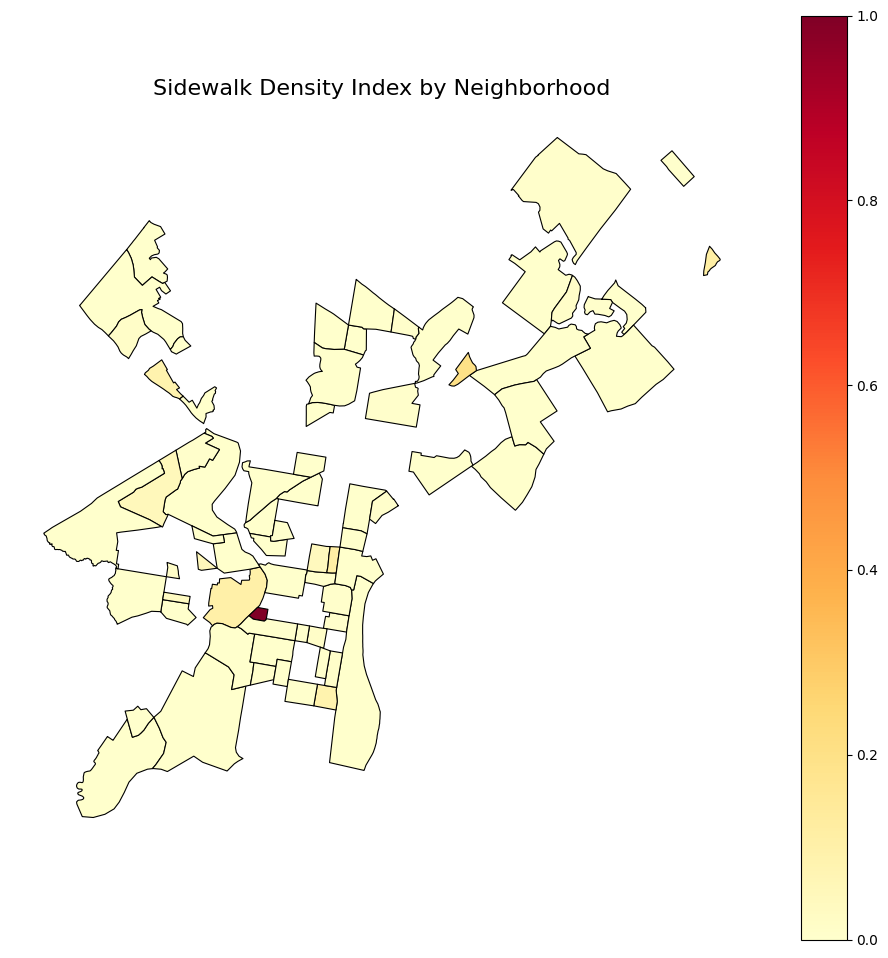

In [319]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Assume your GeoDataFrame is sidewalk_summary
# and it has columns: 'geometry' and 'density_index' (0-1)

# Plot using a colormap
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
sidewalk_summary.plot(
    column='sidewalk_index',          # use the index for color
    cmap='YlOrRd',                   # colormap
    linewidth=0.8,                   # border thickness
    edgecolor='black',
    legend=True,
    ax=ax
)

ax.set_title("Sidewalk Density Index by Neighborhood", fontsize=16)
ax.axis('off')
plt.show()


In [286]:
zeros = (sidewalk_summary['sidewalk_index'] == 0).sum()
print(zeros)


87


In [321]:
# Example: get row with maximum curb_density
max_row = sidewalk_summary.loc[sidewalk_summary['sidewalk_density'].idxmax()]

# View it
print(max_row)


Name                                                         PASCHALL
geometry            POLYGON ((484646.48662186036 4421718.354004865...
length_m                                                     2,069.25
area_m2                                                    260,596.26
sidewalk_density                                                 0.01
sidewalk_index                                                   1.00
Name: 104, dtype: object


In [ ]:
##CURBS

In [343]:
import geopandas as gpd

curbs = gpd.read_file("Curbs.geojson"
).to_crs(epsg=3857)
nocurbs = gpd.read_file("Curbs_No_Cartways.geojson"
).to_crs(epsg=3857)
curbs

,objectid,curbs_poly_,curbs_poly_id,fcode,elev_1,elev_2,elev_3,update_,add_date,chg_src,cp_id,Shape__Area,Shape__Length,geometry
0,1,None,None,9999,"1,000.00",NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26252,411.69,83.46,"POLYGON ((-8379905.294 4846175.211, -8379906.4..."
1,2,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26253,42.54,52.15,"POLYGON ((-8379888.089 4846212.303, -8379888.3..."
2,3,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26254,267.73,408.36,"POLYGON ((-8379662.13 4846252.296, -8379662.53..."
3,4,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26256,709.10,234.47,"POLYGON ((-8378128.326 4847661.877, -8378127.0..."
4,5,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26258,364.43,99.66,"POLYGON ((-8378573.014 4847747.805, -8378573.7..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24587,24588,None,None,9999,0.00,0.00,0.00,NaT,None,None,5,"49,798.20","1,135.25","POLYGON ((-8350234.852 4885678.21, -8350232.62..."
24588,24589,None,None,9999,0.00,0.00,0.00,NaT,None,None,4,"45,909.00","1,002.20","POLYGON ((-8350341.021 4885755.183, -8350337.2..."
24589,24590,None,None,1032,0.00,0.00,0.00,NaT,None,None,3,31.89,24.20,"POLYGON ((-8350337.064 4885762.844, -8350336.4..."
24590,24591,None,None,9999,0.00,0.00,0.00,NaT,None,None,2,"28,823.90",742.02,"POLYGON ((-8350501.983 4885892.195, -8350499.9..."


In [342]:
nocurbs

,OBJECTID,CURBS_POLY,CURBS_PO_1,FCODE,ELEV_1,ELEV_2,ELEV_3,UPDATE_,ADD_DATE,CHG_SRC,CP_ID,Shape__Area,Shape__Length,geometry
0,1,None,None,9999,1000,0,0,2013-01-25 00:00:00+00:00,None,None,26252,411.69,83.46,"POLYGON ((-8379905.294 4846175.211, -8379906.4..."
1,2,None,None,9999,0,0,0,2013-07-02 00:00:00+00:00,None,None,26362,"281,125.53","2,333.26","POLYGON ((-8378080.382 4847808.052, -8378078.1..."
2,3,None,None,9999,1020,0,0,2006-03-23 00:00:00+00:00,None,None,25597,"3,250.10","1,467.02","POLYGON ((-8377454.185 4847774.03, -8377442.19..."
3,4,None,None,9999,1020,0,0,2006-03-23 00:00:00+00:00,None,None,25599,"84,010.97","14,606.51","POLYGON ((-8378104.337 4847923.462, -8378105.0..."
4,5,None,None,9999,1020,0,0,2006-03-28 00:00:00+00:00,None,None,24228,21.09,20.14,"POLYGON ((-8378098.918 4847929.831, -8378101.1..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17350,17351,None,None,9999,0,0,0,NaT,None,None,8,"35,534.50",847.38,"POLYGON ((-8350632.007 4885552.579, -8350631.7..."
17351,17352,None,None,9999,0,0,0,NaT,None,None,7,"25,745.82",652.08,"POLYGON ((-8350412.864 4885610.395, -8350408.0..."
17352,17353,None,None,9999,0,0,0,NaT,None,None,6,"44,781.14",835.40,"POLYGON ((-8350140.275 4885603.045, -8350138.9..."
17353,17354,None,None,9999,0,0,0,NaT,None,None,5,"49,798.19","1,135.25","POLYGON ((-8350234.853 4885678.21, -8350232.62..."


In [352]:
curbs['cartway'] = 1
nocurbs['cartway'] = 0
curbs

,objectid,curbs_poly_,curbs_poly_id,fcode,elev_1,elev_2,elev_3,update_,add_date,chg_src,cp_id,Shape__Area,Shape__Length,geometry,cartway
0,1,None,None,9999,"1,000.00",NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26252,411.69,83.46,"POLYGON ((-8379905.294 4846175.211, -8379906.4...",1
1,2,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26253,42.54,52.15,"POLYGON ((-8379888.089 4846212.303, -8379888.3...",1
2,3,None,None,1012,NaN,NaN,NaN,2013-01-25 00:00:00+00:00,None,None,26254,267.73,408.36,"POLYGON ((-8379662.13 4846252.296, -8379662.53...",1
3,4,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26256,709.10,234.47,"POLYGON ((-8378128.326 4847661.877, -8378127.0...",1
4,5,None,None,1032,NaN,NaN,NaN,2013-01-28 00:00:00+00:00,None,None,26258,364.43,99.66,"POLYGON ((-8378573.014 4847747.805, -8378573.7...",1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24587,24588,None,None,9999,0.00,0.00,0.00,NaT,None,None,5,"49,798.20","1,135.25","POLYGON ((-8350234.852 4885678.21, -8350232.62...",1
24588,24589,None,None,9999,0.00,0.00,0.00,NaT,None,None,4,"45,909.00","1,002.20","POLYGON ((-8350341.021 4885755.183, -8350337.2...",1
24589,24590,None,None,1032,0.00,0.00,0.00,NaT,None,None,3,31.89,24.20,"POLYGON ((-8350337.064 4885762.844, -8350336.4...",1
24590,24591,None,None,9999,0.00,0.00,0.00,NaT,None,None,2,"28,823.90",742.02,"POLYGON ((-8350501.983 4885892.195, -8350499.9...",1


In [378]:
import geopandas as gpd

combined = gpd.GeoDataFrame(
    pd.concat([curbs, nocurbs], ignore_index=True),
    crs=curbs.crs
)
combined.geometry

0        POLYGON ((-8379905.294 4846175.211, -8379906.4...
1        POLYGON ((-8379888.089 4846212.303, -8379888.3...
2        POLYGON ((-8379662.13 4846252.296, -8379662.53...
3        POLYGON ((-8378128.326 4847661.877, -8378127.0...
4        POLYGON ((-8378573.014 4847747.805, -8378573.7...
                               ...                        
41942    POLYGON ((-8350632.007 4885552.579, -8350631.7...
41943    POLYGON ((-8350412.864 4885610.395, -8350408.0...
41944    POLYGON ((-8350140.275 4885603.045, -8350138.9...
41945    POLYGON ((-8350234.853 4885678.21, -8350232.62...
41946    POLYGON ((-8350341.021 4885755.183, -8350337.2...
Name: geometry, Length: 41947, dtype: geometry

C:\Users\kalmanj\AppData\Local\Temp\ipykernel_17932\3306804503.py:14: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend()
C:\Users\kalmanj\AppData\Local\Temp\ipykernel_17932\3306804503.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


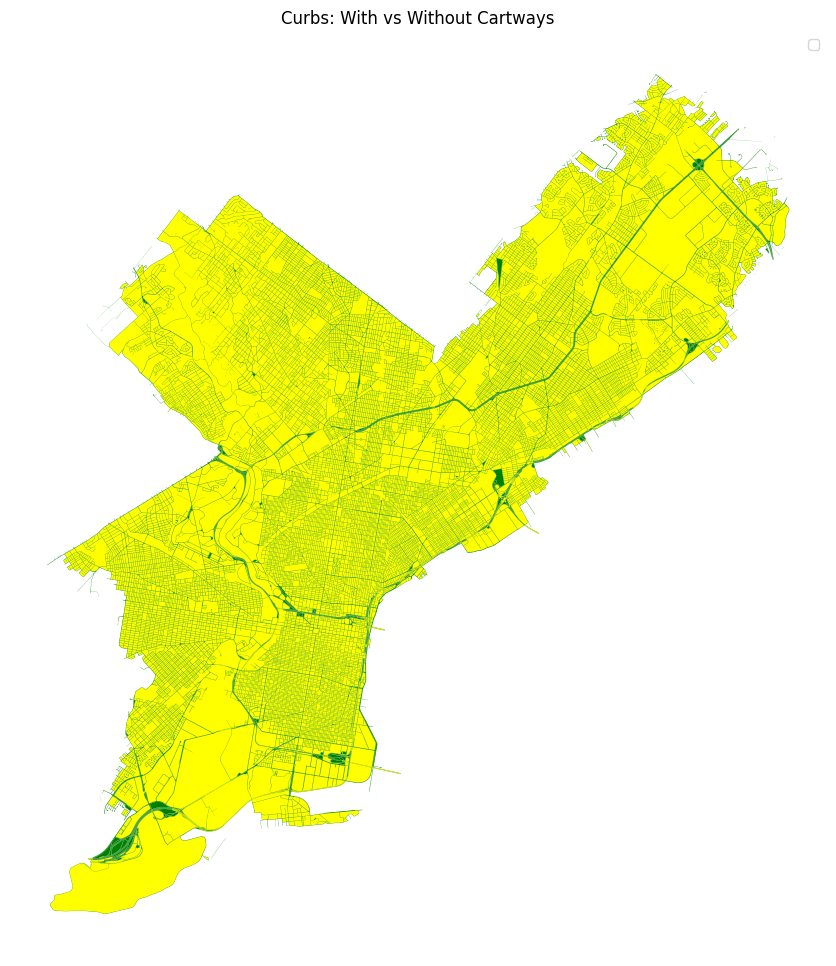

In [366]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 12))

combined[combined["cartway"] == 1].plot(
    ax=ax, color="green", linewidth=0.7, label="With Cartway"
)

combined[combined["cartway"] == 0].plot(
    ax=ax, color="yellow", linewidth=0.7, label="Without Cartway"
)

ax.set_title("Curbs: With vs Without Cartways")
ax.legend()
ax.axis("off")
plt.show()


In [381]:
tracts = tracts.to_crs(3857)

curbs_joined = gpd.sjoin(combined, tracts[["Name", "geometry"]], 
                         how="right", 
                         predicate="intersects")
curbs_joined.Shape__Area

0       3,601.96
0         127.16
0       1,530.76
0         548.06
0       1,474.75
         ...    
157    24,011.90
157   399,469.46
157    86,700.95
157    33,913.66
157    59,720.09
Name: Shape__Area, Length: 44286, dtype: float64

In [382]:
total_area = (
    curbs_joined.groupby("Name")["Shape__Area"]
    .sum()
    .reset_index(name="total_curb_area")
)


In [383]:
cartway_area = (
    curbs_joined[curbs_joined["cartway"] == 1]
    .groupby("Name")["Shape__Area"]
    .sum()
    .reset_index(name="cartway_area")
)


In [384]:
summary = tracts[["Name", "geometry"]].merge(total_area, on="Name", how="left")
summary = summary.merge(cartway_area, on="Name", how="left")
summary

,Name,geometry,total_curb_area,cartway_area
0,LAWNDALE,"POLYGON ((-8358553.218 4873230.139, -8358861.1...","32,898,698.54","27,095,888.25"
1,ASTON_WOODBRIDGE,"POLYGON ((-8349918.77 4873746.906, -8349919.81...","30,649,804.84","25,959,130.58"
2,CARROLL_PARK,"POLYGON ((-8374201.54 4862629.945, -8373476.79...","14,754,256.79","12,878,404.75"
3,CHESTNUT_HILL,"POLYGON ((-8372648.259 4878500.7, -8372642.137...","59,068,870.39","43,136,848.45"
4,BURNHOLME,"POLYGON ((-8358722.064 4875917.543, -8358711.6...","24,440,279.79","22,849,155.71"
...,...,...,...,...
153,DICKINSON_NARROWS,"POLYGON ((-8365930.897 4855362.957, -8365987.3...","7,300,951.34","6,647,949.09"
154,GARDEN_COURT,"POLYGON ((-8372801.078 4859132.007, -8372860.9...","11,842,045.39","11,421,707.32"
155,WISSAHICKON_HILLS,"POLYGON ((-8373463.387 4871402.731, -8373522.9...","30,411,549.68","28,788,932.64"
156,DEARNLEY_PARK,"POLYGON ((-8376943.188 4872273.448, -8376802.5...","33,203,078.59","30,183,775.00"


In [385]:
summary["cartway_density"] = summary["cartway_area"] / summary["total_curb_area"]
summary.loc[summary["total_curb_area"] == 0, "cartway_density"] = 0


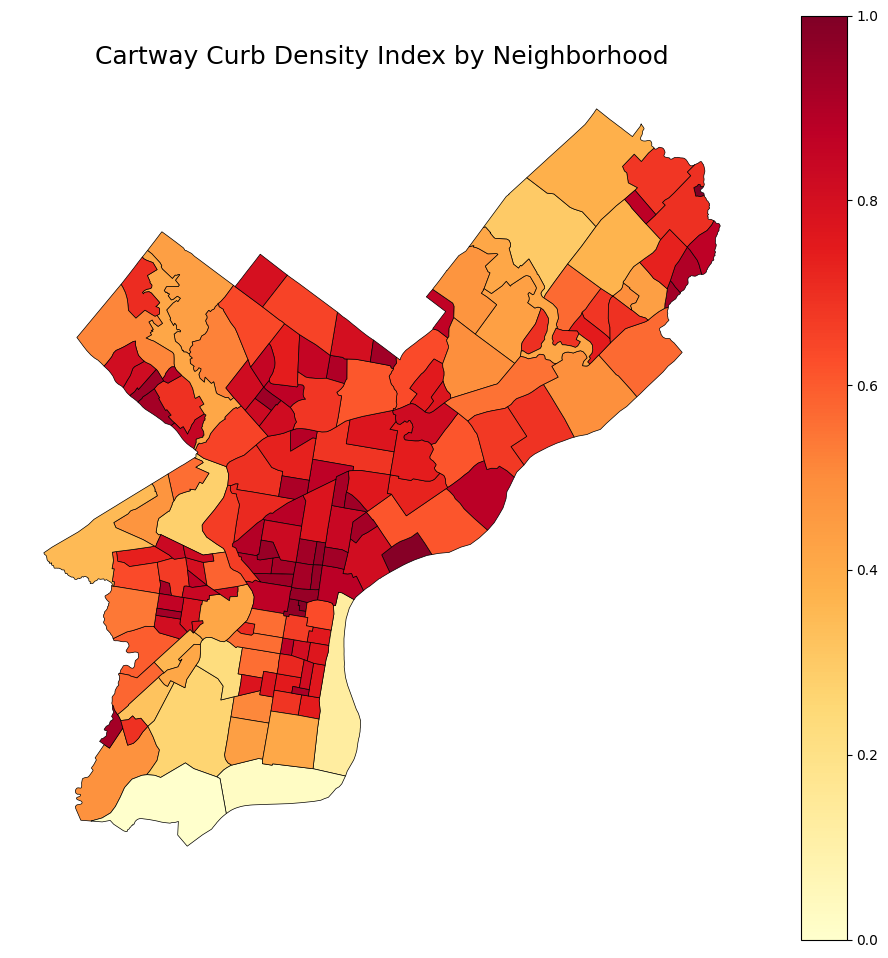

In [387]:
min_val = summary["cartway_density"].replace(0, pd.NA).min()
max_val = summary["cartway_density"].max()

summary["cartway_density_index"] = (
    (summary["cartway_density"] - min_val) /
    (max_val - min_val)
)

summary["cartway_density_index"] = summary["cartway_density_index"].fillna(0)

# -----------------------------
# 11. Plot it
# -----------------------------
fig, ax = plt.subplots(1, 1, figsize=(12, 12))
summary.plot(
    column="cartway_density_index",
    cmap="YlOrRd",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

ax.set_title("Cartway Curb Density Index by Neighborhood", fontsize=18)
ax.axis("off")
plt.show()
